# Battery siting scores — analysis

Reads the pinned `out/battery_siting_scores_additive_*.csv` from the locational-siting scorer and answers:

1. **Where are the best locations?** — top-ranked batteries by locational value.
2. **How big are the relative differences in profit?** — spread across the fleet.
3. **Which regions of Germany score best?** — a choropleth + density heatmap.

---

### What the score actually is (read this first)

The scorer values each battery as a **price-taker arbitrage operator** against a *local* effective
price `π̂` = zonal intraday price **bent by nearby redispatch events** (a proxy for the nodal price
Germany's single bidding zone hides). For each battery it reports:

| column | meaning |
|---|---|
| `V_proxy_eur_per_year` | annual arbitrage **profit** against the local price π̂ (€/yr) |
| `V_copperplate_proxy_eur` | the **same proxy estimator** on the spatially-flat zonal price (the "no-congestion" baseline) |
| `dV_proxy_eur_per_year` | **`V − V_copperplate_proxy`** — the *locational premium* created by congestion (€/yr) |
| `rank_by_dV` | fleet rank, 1 = best, keyed on `dV` |

Configuration of this run:

- **Wedge = additive, volume-weighted, calibrated:** `π̂[n,t] = p_base[t] + α · Σ_g K(d(n,g))·sign_g·MW_g[t]`.
  A flat €/MWh shift (independent of price level) so a surplus neighbourhood lowers the *cheap charging*
  hours as much as the peaks — surplus regions now get full cheap-charging credit. Weighted by each
  event's MW. `α` is **calibrated** so the mean local premium ≈ BNetzA redispatch cost-per-energy
  (~100 €/MWh). *This run is the unclipped variant — absolute `dV` magnitudes are inflated by a few
  hub sites; treat the values as ordinal, the **ranking** is the signal.*
- **Kernel = `ptdf`** — electrical distance `‖PTDF[:,n] − PTDF[:,g]‖₂` over the DE 220/380 kV topology.
- **Window = 2021-10-01 → 2025-12-31** (≈ 4.25 yr) — after **Redispatch 2.0 / NABEG** entered force.
- **`dV` signed**: positive where nearby congestion raises arbitrage value, negative where it lowers it.
- **All batteries scored at fixed `score_power_mw = 50 MW`** → pure locational signal; ranking by `V`
  and by `dV` is identical.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import glob, os

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

HERE = Path.cwd()
OUT = HERE / "out"
if not OUT.exists():  # allow running from repo root
    OUT = HERE / "battery_siting_score" / "out"

# Pin to the unclipped additive (volume-weighted, calibrated) run. Set PIN=None to
# fall back to "newest timestamped file" instead.
PIN = "battery_siting_scores_additive_20260625_112721.csv"
if PIN and (OUT / PIN).exists():
    CSV = OUT / PIN
else:
    cands = sorted(glob.glob(str(OUT / "battery_siting_scores_*.csv")), key=os.path.getmtime)
    CSV = Path(cands[-1]) if cands else (OUT / "battery_siting_scores.csv")
print("loading:", CSV.name)

df = pd.read_csv(CSV)

# Canonical score = the proxy columns (this run is method='proxy').
df["V_per_year"]  = df["V_proxy_eur_per_year"]      # absolute arbitrage profit @ 50 MW
df["dV_per_year"] = df["dV_proxy_eur_per_year"]     # locational premium @ 50 MW (vs proxy copperplate)
df["is_solar_colocated"] = df["colocated_solar_id"].notna()

# Proxy copperplate (the like-for-like baseline that dV is measured against).
cp_col = "V_copperplate_proxy_eur" if "V_copperplate_proxy_eur" in df.columns else "V_copperplate_eur"
# Derive the window length from the data (V_total / V_per_year) so it tracks the config window.
n_years = float((df["V_proxy_eur"] / df["V_proxy_eur_per_year"]).iloc[0])

print(f"{len(df)} batteries scored | normalised to {df.score_power_mw.iloc[0]:.0f} MW / 4h units | window {n_years:.2f} yr")
print(f"proxy copperplate baseline (constant): {df[cp_col].iloc[0]/n_years:,.0f} EUR/yr  @50 MW")
print(f"dV/yr range: {df.dV_per_year.min():,.0f} .. {df.dV_per_year.max():,.0f}  "
      f"({(df.dV_per_year<0).mean()*100:.0f}% negative)")
df.head(3)


loading: battery_siting_scores_additive_20260625_112721.csv
1281 batteries scored | normalised to 50 MW / 4h units | window 4.25 yr
proxy copperplate baseline (constant): 6,422,313 EUR/yr  @50 MW
dV/yr range: -63,352 .. 224,032,578  (13% negative)


,battery_idx,score_power_mw,V_eur,V_copperplate_eur,dV_eur,steps_nonzero_wedge,mean_abs_wedge_eur_per_mwh,frac_pos_wedge,frac_neg_wedge,V_eur_per_year,...,lon,state,status_cat,commissioning_date,EinheitMastrNummer,colocated_solar_id,rank_by_dV,V_per_year,dV_per_year,is_solar_colocated
0,66,50.0,NaN,34223283.75,NaN,112282,2289.256170,0.158383,0.594743,NaN,...,9.217374,Schleswig-Holstein,active,2023-01-19,SEE984446277410,NaN,1,2.304549e+08,2.240326e+08,False
1,14,50.0,NaN,34223283.75,NaN,112282,1421.339968,0.421711,0.331415,NaN,...,7.305250,Niedersachsen,active,2022-12-14,SEE905843309764,NaN,2,1.698125e+08,1.633902e+08,False
2,273,50.0,NaN,34223283.75,NaN,112282,1421.339968,0.421711,0.331415,NaN,...,7.319417,Niedersachsen,active,2025-12-10,SEE960369932407,NaN,3,1.698125e+08,1.633902e+08,False


## 1. Fleet overview

A quick orientation before the ranking: how many batteries, in which states, and how the locational
premium is distributed. `dV_per_year` is now **signed and roughly centred on zero** — positive sites
sit near `erhöhen`/shortage congestion that *amplifies* the local price spread (more arbitrage value),
negative sites near `reduzieren`/surplus congestion that *shaves* the peaks. The dashed line marks the
fleet median.


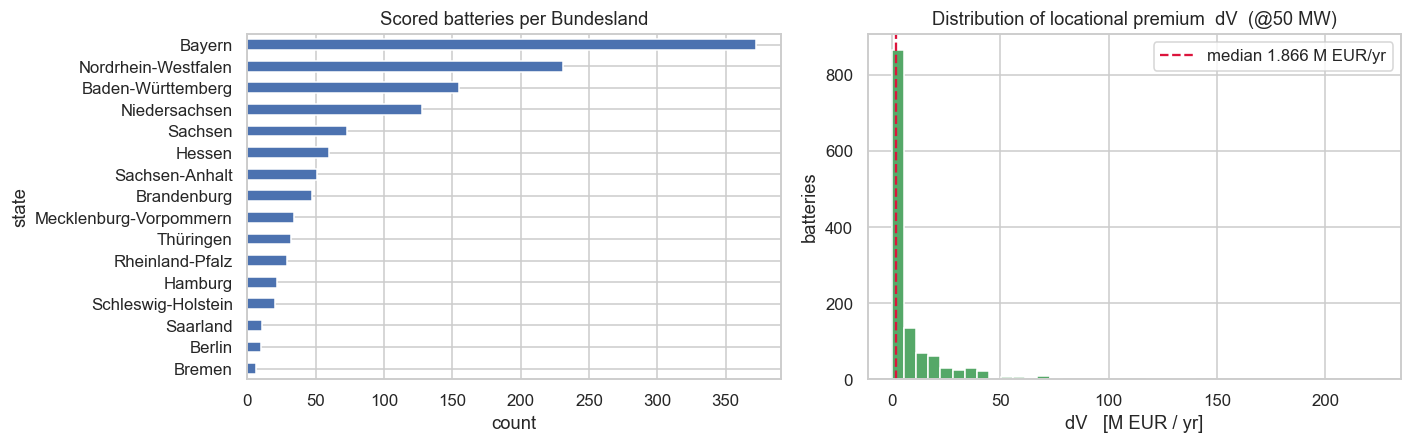

        V_per_year  dV_per_year  p_bar_mw
count       1281.0       1281.0    1281.0
mean    15457349.0    9035037.0       3.0
std     19116762.0   19116762.0       9.0
min      6358960.0     -63352.0       0.0
25%      6497441.0      75128.0       0.0
50%      8288020.0    1865707.0       0.0
75%     15043249.0    8620937.0       2.0
max    230454891.0  224032578.0     174.0


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

df["state"].value_counts().plot.barh(ax=ax[0], color="#4C72B0")
ax[0].invert_yaxis()
ax[0].set_title("Scored batteries per Bundesland")
ax[0].set_xlabel("count")

ax[1].hist(df["dV_per_year"] / 1e6, bins=40, color="#55A868", edgecolor="white")
ax[1].axvline(df["dV_per_year"].median()/1e6, color="crimson", ls="--", lw=1.5,
              label=f"median {df.dV_per_year.median()/1e6:.3f} M EUR/yr")
ax[1].set_title("Distribution of locational premium  dV  (@50 MW)")
ax[1].set_xlabel("dV   [M EUR / yr]"); ax[1].set_ylabel("batteries")
ax[1].legend()
plt.tight_layout(); plt.show()

print(df[["V_per_year", "dV_per_year", "p_bar_mw"]].describe().round(0))


## 2. Best locations

Ranked by `dV` (= by `V`, identical ordering). The table is the direct answer to *"what are the best
locations?"*. The bar chart shows each top site's **locational premium `dV`** directly (now positive at
the top of the fleet).


In [3]:
cols = ["rank_by_dV", "name", "state", "lat", "lon", "p_bar_mw",
        "V_per_year", "dV_per_year", "is_solar_colocated"]
top = df.sort_values("rank_by_dV").head(20)[cols].reset_index(drop=True)

show = top.copy()
show["V_per_year"]  = (show["V_per_year"]/1e6).round(3)
show["dV_per_year"] = (show["dV_per_year"]/1e6).round(3)
show = show.rename(columns={"rank_by_dV": "rank", "p_bar_mw": "nameplate_MW",
                            "V_per_year": "V [M EUR/yr]", "dV_per_year": "dV [M EUR/yr]",
                            "is_solar_colocated": "solar-coloc"})
show


,rank,name,state,lat,lon,nameplate_MW,V [M EUR/yr],dV [M EUR/yr],solar-coloc
0,1,Büttel Speicher,Schleswig-Holstein,53.909541,9.217374,12.00000,230.455,224.033,False
1,2,Batteriespeicher Emsland,Niedersachsen,52.480270,7.305250,45.00000,169.812,163.390,False
2,3,Quantum-Batterie-Lingen,Niedersachsen,52.505691,7.319417,2.50000,169.812,163.390,False
3,4,Stromspeicher1010,Brandenburg,51.550979,14.376030,0.19360,143.681,137.259,False
4,5,PVA U6 BESS,Sachsen,51.450188,14.273385,0.10800,143.681,137.259,False
5,6,Big Battery Lausitz,Brandenburg,51.531359,14.348723,66.00000,143.681,137.259,False
6,7,Batteriespeicher-01 - Dorn,Baden-Württemberg,47.625147,9.662165,0.26400,140.238,133.816,False
7,8,Stromspeicherei 001,Baden-Württemberg,47.600866,9.602676,0.15800,140.238,133.816,False
8,9,NS_03_250_522_Regnitz,Baden-Württemberg,47.634630,9.735874,0.25000,140.238,133.816,False
9,10,ABR980748679150,Bayern,48.767522,11.634352,0.27600,124.556,118.134,False


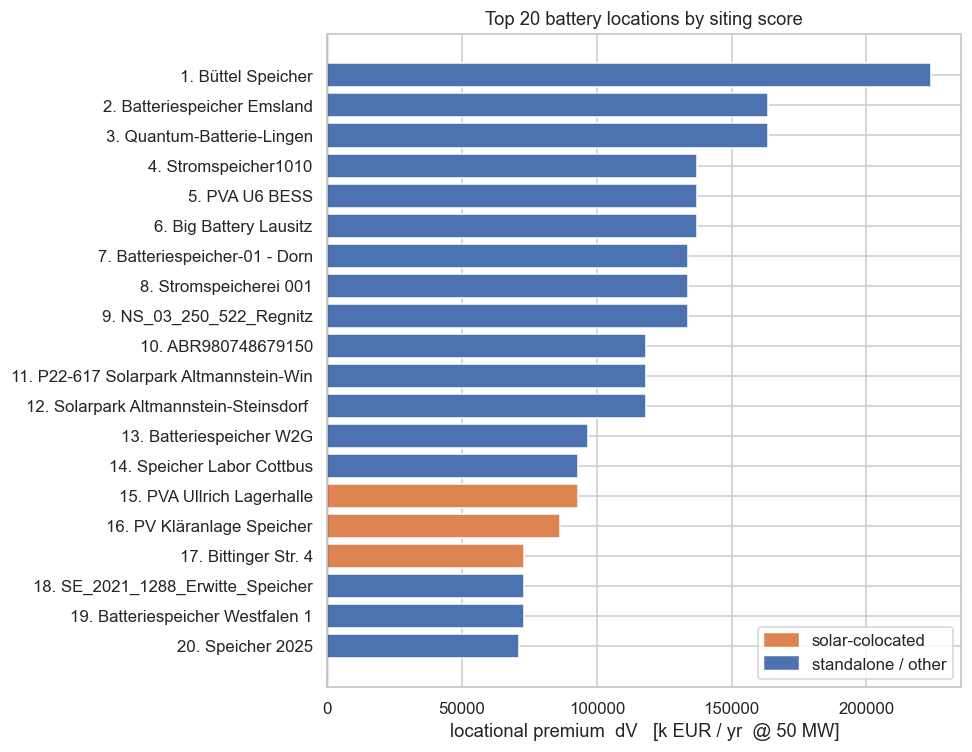

In [4]:
# Bar chart: locational premium dV of each top site (signed).
t = df.sort_values("rank_by_dV").head(20).copy()
t["dV_k"] = t["dV_per_year"] / 1e3

fig, ax = plt.subplots(figsize=(9, 7))
colors = np.where(t["is_solar_colocated"], "#DD8452", "#4C72B0")
ax.barh(range(len(t)), t["dV_k"], color=colors)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f"{r}. {n[:34]}" for r, n in zip(t.rank_by_dV, t.name)])
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("locational premium  dV   [k EUR / yr  @ 50 MW]")
ax.set_title("Top 20 battery locations by siting score")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#DD8452", label="solar-colocated"),
                   Patch(color="#4C72B0", label="standalone / other")], loc="lower right")
plt.tight_layout(); plt.show()


## 3. Relative differences in profit

All sites are scored at the same 50 MW, so differences here are **pure siting quality**, not size.
Two complementary framings:

- **Level (`V`)** — absolute arbitrage profit against the local price. This is the "how much money"
  number; the spread between best and worst sites is what siting choice is worth.
- **Premium (`dV`)** — value attributable to *congestion at that location*.

Because `V` differs from `dV` only by the constant copperplate baseline, the *percentage* spread looks
small on `V` (the baseline dominates) but is the entire story on `dV`. We report both.


In [5]:
V = df["V_per_year"]
dV = df["dV_per_year"]
best, worst, med = V.max(), V.min(), V.median()

print("=== Absolute arbitrage profit V (@50 MW) ===")
print(f"  best  : {best:,.0f} EUR/yr   ({df.sort_values('rank_by_dV').iloc[0]['name']})")
print(f"  median: {med:,.0f} EUR/yr")
print(f"  worst : {worst:,.0f} EUR/yr")
print(f"  best vs worst : +{(best-worst):,.0f} EUR/yr  (+{(best/worst-1)*100:.2f}% on V)")
print(f"  best vs median: +{(best-med):,.0f} EUR/yr  (+{(best/med-1)*100:.2f}% on V)")

print("\n=== Locational premium dV (the part siting controls) ===")
print(f"  best dV vs worst dV spread: {(dV.max()-dV.min()):,.0f} EUR/yr")
print(f"  top-decile cutoff : {dV.quantile(0.9):,.0f} EUR/yr")
print(f"  bottom-decile cut : {dV.quantile(0.1):,.0f} EUR/yr")
# How much better is a top-10% site than a median site, measured on the premium?
gain = (dV.quantile(0.9) - dV.median())
print(f"  moving median -> top-decile site gains {gain:,.0f} EUR/yr of locational value (@50 MW)")


=== Absolute arbitrage profit V (@50 MW) ===
  best  : 230,454,891 EUR/yr   (Büttel Speicher)
  median: 8,288,020 EUR/yr
  worst : 6,358,960 EUR/yr
  best vs worst : +224,095,930 EUR/yr  (+3524.10% on V)
  best vs median: +222,166,871 EUR/yr  (+2680.58% on V)

=== Locational premium dV (the part siting controls) ===
  best dV vs worst dV spread: 224,095,930 EUR/yr
  top-decile cutoff : 27,590,334 EUR/yr
  bottom-decile cut : -1,028 EUR/yr
  moving median -> top-decile site gains 25,724,627 EUR/yr of locational value (@50 MW)


C:\Users\wachs\AppData\Local\Temp\ipykernel_40100\323818782.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df.loc[~df.is_solar_colocated,"dV_per_year"]/1e6,


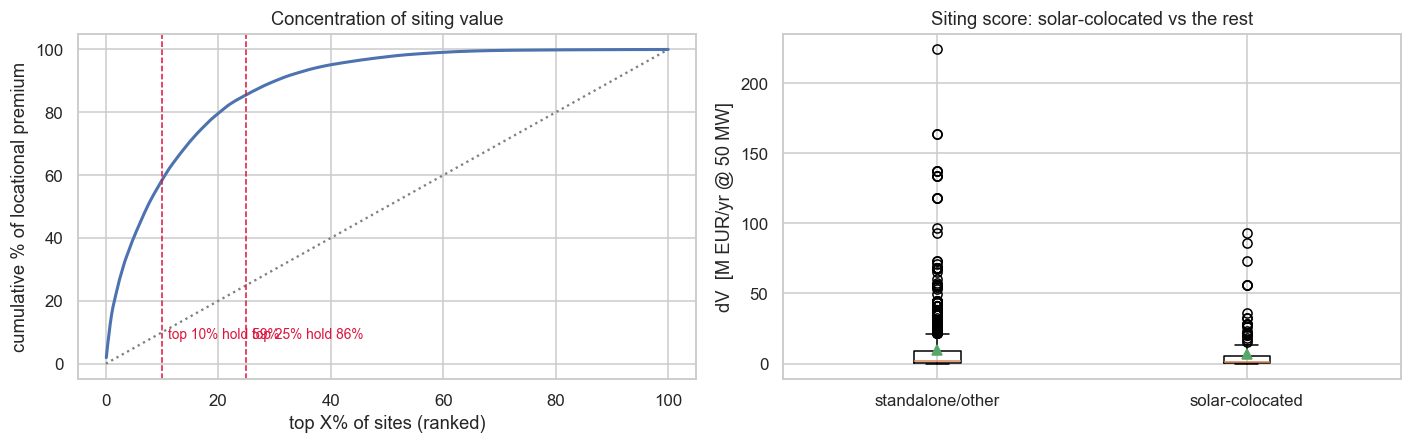

In [6]:
# Lorenz-style view: cumulative share of total locational premium vs cumulative share of sites.
# Shift dV to be non-negative (premium above worst site) so a cumulative share is meaningful.
prem = (df["dV_per_year"] - df["dV_per_year"].min()).sort_values(ascending=False).values
cum = np.cumsum(prem) / prem.sum()
x = np.arange(1, len(cum)+1) / len(cum)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(x*100, cum*100, color="#4C72B0", lw=2)
ax[0].plot([0,100],[0,100], ls=":", color="grey")
ax[0].set_xlabel("top X% of sites (ranked)"); ax[0].set_ylabel("cumulative % of locational premium")
ax[0].set_title("Concentration of siting value")
for q in (10, 25):
    ax[0].axvline(q, color="crimson", ls="--", lw=1)
    ax[0].text(q+1, 8, f"top {q}% hold {cum[int(q/100*len(cum))]*100:.0f}%", color="crimson", fontsize=9)

ax[1].boxplot([df.loc[~df.is_solar_colocated,"dV_per_year"]/1e6,
               df.loc[df.is_solar_colocated,"dV_per_year"]/1e6],
              labels=["standalone/other", "solar-colocated"], showmeans=True)
ax[1].set_ylabel("dV  [M EUR/yr @ 50 MW]")
ax[1].set_title("Siting score: solar-colocated vs the rest")
plt.tight_layout(); plt.show()


### Optional: profit at the *real* nameplate

The score is normalised to 50 MW. If instead we scale the per-MW value by each battery's true
`p_bar_mw`, we get an "expected arbitrage value **at the size actually built**" view. This re-ranks
toward the big utility-scale units and is closer to a real-money figure (still a proxy, still ignores
4 h-duration assumptions for non-4 h devices).


In [7]:
df["V_per_year_per_MW"] = df["V_per_year"] / df["score_power_mw"]
df["V_at_real_size"]     = df["V_per_year_per_MW"] * df["p_bar_mw"]

real = (df.sort_values("V_at_real_size", ascending=False)
          .head(15)[["name","state","p_bar_mw","rank_by_dV","V_at_real_size"]]
          .reset_index(drop=True))
real["V_at_real_size_M_EUR_yr"] = (real.pop("V_at_real_size")/1e6).round(2)
real


,name,state,p_bar_mw,rank_by_dV,V_at_real_size_M_EUR_yr
0,Batteriespeicher Westfalen 1,Nordrhein-Westfalen,174.24,19,276.58
1,Big Battery Lausitz,Brandenburg,66.00,6,189.66
2,Batteriespeicher Emsland,Niedersachsen,45.00,2,152.83
3,Batteriespeicher Neurath,Nordrhein-Westfalen,99.00,29,146.42
4,Büttel Speicher,Schleswig-Holstein,12.00,1,55.31
5,BESS Leuna 1,Sachsen-Anhalt,50.94,54,51.42
6,BESS Leuna 2,Sachsen-Anhalt,50.94,55,51.42
7,BESS Krumpa I,Sachsen-Anhalt,50.94,85,43.11
8,Batteriepark Metelen,Nordrhein-Westfalen,92.50,411,22.45
9,SMAREG4 Wartburgspeicher Eisenach,Thüringen,60.00,307,18.26


## 4. Heatmap of Germany

Two map views:

1. **Choropleth** — mean siting score per Bundesland (where the *good* regions are on average).
2. **Point + density heatmap** — every battery coloured by score, over a kernel-density surface, so
   clusters of high-value sites stand out.

The Bundesländer boundary is fetched once from a public GeoJSON and cached to `out/` so the notebook
re-runs offline afterwards.


In [8]:
import json, urllib.request
import geopandas as gpd

GEO = (CSV.parent / "bundeslaender.geojson")
URL = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/2_hoch.geo.json"
if not GEO.exists():
    try:
        urllib.request.urlretrieve(URL, GEO)
        print("downloaded + cached boundary ->", GEO.name)
    except Exception as e:
        print("could not download boundary:", e)

states_gdf = gpd.read_file(GEO) if GEO.exists() else None
if states_gdf is not None:
    # the GeoJSON names the state field 'name'
    name_col = "name" if "name" in states_gdf.columns else states_gdf.columns[0]
    print("boundary loaded:", len(states_gdf), "states; name col =", name_col)


boundary loaded: 16 states; name col = name


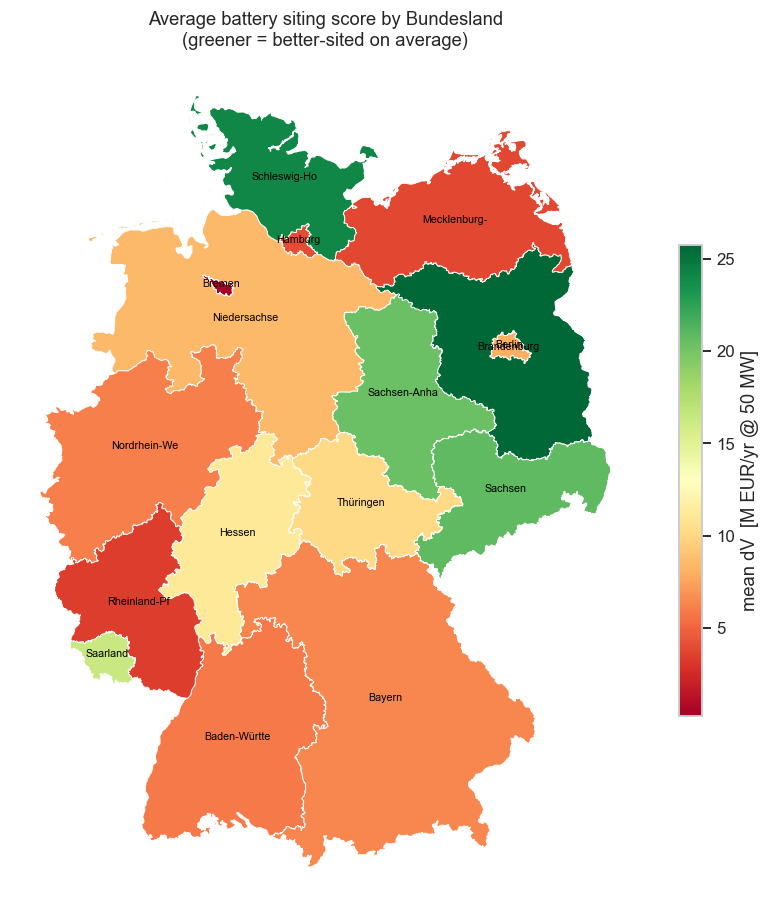

state
Brandenburg               25.767
Schleswig-Holstein        24.107
Sachsen                   20.795
Sachsen-Anhalt            20.442
Saarland                  16.351
Hessen                    11.156
Thüringen                 10.140
Niedersachsen              8.450
Berlin                     7.950
Bayern                     6.325
Nordrhein-Westfalen        6.103
Baden-Württemberg          5.862
Hamburg                    3.914
Mecklenburg-Vorpommern     3.798
Rheinland-Pfalz            3.363
Bremen                     0.215


In [9]:
# Choropleth: mean dV per state.
state_mean = (df.groupby("state")["dV_per_year"].mean() / 1e6)

fig, ax = plt.subplots(figsize=(7.5, 9))
if states_gdf is not None:
    g = states_gdf.copy()
    g["score"] = g[name_col].map(state_mean)
    g.plot(column="score", cmap="RdYlGn", legend=True, ax=ax,
           edgecolor="white", linewidth=0.6, missing_kwds={"color": "lightgrey"},
           legend_kwds={"label": "mean dV  [M EUR/yr @ 50 MW]", "shrink": 0.5})
    for _, r in g.iterrows():
        ax.annotate(r[name_col][:12], xy=(r.geometry.centroid.x, r.geometry.centroid.y),
                    ha="center", fontsize=7, color="black")
    ax.set_axis_off()
else:
    state_mean.sort_values().plot.barh(ax=ax, color="#55A868")
    ax.set_xlabel("mean dV [M EUR/yr]")
ax.set_title("Average battery siting score by Bundesland\n(greener = better-sited on average)")
plt.tight_layout(); plt.show()

print(state_mean.sort_values(ascending=False).round(3).to_string())


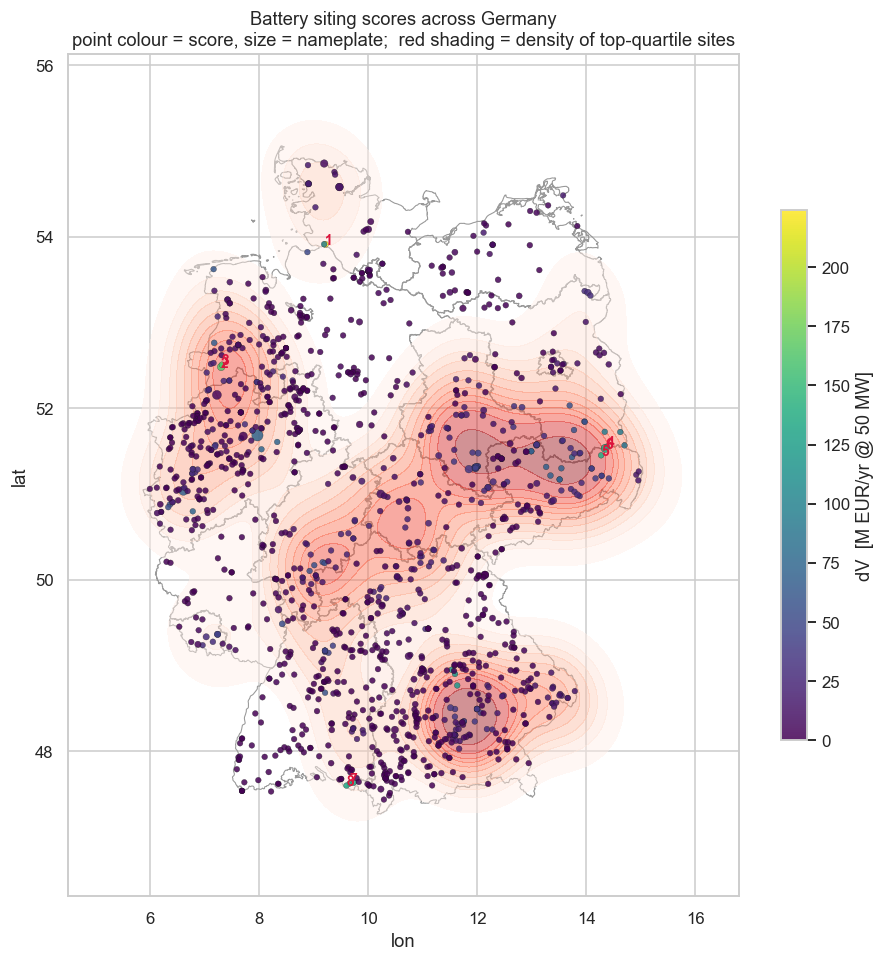

In [10]:
# Point map + density: every battery, coloured by dV, over a KDE surface.
fig, ax = plt.subplots(figsize=(8.5, 10))

if states_gdf is not None:
    states_gdf.boundary.plot(ax=ax, color="0.6", linewidth=0.7, zorder=1)

# KDE density of the *top quartile* sites, to highlight where value concentrates.
top_q = df[df["dV_per_year"] >= df["dV_per_year"].quantile(0.75)]
try:
    sns.kdeplot(data=top_q, x="lon", y="lat", fill=True, cmap="Reds",
                alpha=0.45, levels=12, thresh=0.05, bw_adjust=0.7, ax=ax, zorder=2)
except Exception as e:
    print("kde skipped:", e)

sc = ax.scatter(df["lon"], df["lat"], c=df["dV_per_year"]/1e6, cmap="viridis",
                s=14 + 40*(df["p_bar_mw"]/df["p_bar_mw"].max()),
                edgecolor="k", linewidth=0.2, alpha=0.85, zorder=3)
cb = plt.colorbar(sc, ax=ax, shrink=0.5)
cb.set_label("dV  [M EUR/yr @ 50 MW]")

# label the top 8 sites
for _, r in df.sort_values("rank_by_dV").head(8).iterrows():
    ax.annotate(f"{int(r.rank_by_dV)}", (r.lon, r.lat), fontsize=9, fontweight="bold",
                color="crimson", zorder=4)

ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title("Battery siting scores across Germany\n"
             "point colour = score, size = nameplate;  red shading = density of top-quartile sites")
ax.set_aspect(1/np.cos(np.radians(df.lat.mean())))
plt.tight_layout(); plt.show()


### Interactive heatmap (folium)

A weighted heatmap you can pan/zoom, saved to `out/siting_heatmap.html`. Weights are the per-site
premium above the worst site, so hotter = better-sited. (Requires internet for the basemap tiles; the
HTML file is self-contained for the data layer.)


In [11]:
try:
    import folium
    from folium.plugins import HeatMap
    w = (df["dV_per_year"] - df["dV_per_year"].min())
    w = (w / w.max()).fillna(0)
    m = folium.Map(location=[df.lat.mean(), df.lon.mean()], zoom_start=6, tiles="CartoDB positron")
    HeatMap(list(zip(df.lat, df.lon, w)), radius=18, blur=14, min_opacity=0.3).add_to(m)
    # mark the top 10
    for _, r in df.sort_values("rank_by_dV").head(10).iterrows():
        folium.CircleMarker([r.lat, r.lon], radius=4, color="crimson", fill=True,
                            popup=f"#{int(r.rank_by_dV)} {r['name']} ({r.state})").add_to(m)
    out_html = CSV.parent / "siting_heatmap.html"
    m.save(str(out_html))
    print("saved:", out_html)
    m
except Exception as e:
    print("folium map skipped:", e)


saved: C:\Users\wachs\Documents\TUM\Seminar EM\ALLES_NEU\battery_siting_score\out\siting_heatmap.html


## 4c. Fleet-independent siting surface (grid)

Everything above scores the batteries **that exist**, so the maps mix two signals: *where good
locations are* and *where the fleet happens to be dense*. This section removes the second signal.

`score_grid.py` lays a regular lat/lon grid over Germany and scores **every cell** as a standardized
50 MW battery — so the result is a pure "value of putting a battery **here**" field that does not
depend on how many batteries exist or where they sit. Two things make it genuinely fleet-independent:

1. **α is frozen from the fleet.** The additive wedge constant is calibrated **once** on the real fleet
   (anchored to BNetzA ≈ 100 €/MWh) and then **reused** for the grid, so grid and fleet stay on one
   absolute scale regardless of grid resolution. (Stored in the `.meta.json` sidecar.)
2. **The score is per electrical bus.** Under the PTDF kernel the value is a function of the snapped
   transmission bus, so the surface is effectively a **Voronoi tessellation of bus service areas** —
   the honest spatial resolution of this model. A 0.1° grid (~4 600 cells) collapses to ~600 buses.

Regenerate with: `python -m battery_siting_score.score_grid --step-deg 0.1`


In [ ]:
# Load the newest grid surface (written by score_grid.py) and render it as a
# filled heatmap. This score does NOT depend on the fleet count or on where
# batteries sit: a regular lat/lon grid is scored at 50 MW with alpha frozen
# from the real fleet's calibration (see the .meta.json sidecar).
import glob, os, json

gcands = sorted(glob.glob(str(OUT / "grid_siting_scores_*.csv")), key=os.path.getmtime)
assert gcands, ("no grid_siting_scores_*.csv in out/ -- run first:\n"
                "    python -m battery_siting_score.score_grid --step-deg 0.1")
GCSV = Path(gcands[-1])
g = pd.read_csv(GCSV)
meta_path = GCSV.with_name(GCSV.stem + ".meta.json")
gmeta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
print("grid:", GCSV.name, "|", gmeta.get("n_grid_cells"), "cells ->",
      gmeta.get("n_unique_buses"), "unique buses |",
      f"alpha frozen = {gmeta.get('alpha_frozen_eur_per_mwh_per_unit'):.4g}"
      if gmeta else "")

# Pivot the (lat, lon) long table back to a 2-D raster; NaN cells (outside the
# DE polygon) stay transparent. dV in M EUR/yr.
piv  = g.pivot_table(index="lat", columns="lon", values="dV_proxy_eur_per_year")
lons, lats = piv.columns.values, piv.index.values
Z = piv.values / 1e6
vmax = float(np.nanpercentile(Z, 98))   # robust ceiling: a few hub buses dominate the raw max

fig, ax = plt.subplots(figsize=(8.5, 10))
pcm = ax.pcolormesh(lons, lats, Z, cmap="viridis", vmin=0, vmax=vmax, shading="nearest", zorder=1)
if states_gdf is not None:
    states_gdf.boundary.plot(ax=ax, color="white", linewidth=0.7, zorder=2)
# faint overlay of the actual fleet, to contrast "value of location" vs "where built"
ax.scatter(df["lon"], df["lat"], s=5, c="crimson", alpha=0.35, linewidth=0, zorder=3,
           label=f"existing batteries (n={len(df)})")
cb = plt.colorbar(pcm, ax=ax, shrink=0.5)
cb.set_label(f"locational premium dV  [M EUR/yr @ 50 MW]  (colour clipped at p98 = {vmax:.2f})")
ax.set_aspect(1 / np.cos(np.radians(float(np.mean(lats)))))
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title("Fleet-independent battery siting surface\n"
             "every grid cell scored at 50 MW; alpha frozen from the real fleet\n"
             "(red dots = where batteries actually are — note value ≠ buildout)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# Interactive fleet-independent surface -> out/grid_siting_heatmap.html
# Weight = per-cell premium, percentile-normalised. Because the grid is spatially
# uniform, the heat reflects LOCATION VALUE only, not where batteries were built.
try:
    import folium
    from folium.plugins import HeatMap
    wv = g["dV_proxy_eur_per_year"].clip(lower=0)
    wv = (wv / np.nanpercentile(wv, 98)).clip(0, 1).fillna(0)
    mg = folium.Map(location=[g.lat.mean(), g.lon.mean()], zoom_start=6, tiles="CartoDB positron")
    HeatMap(list(zip(g.lat, g.lon, wv)), radius=12, blur=10, min_opacity=0.25).add_to(mg)
    out_html = OUT / "grid_siting_heatmap.html"
    mg.save(str(out_html))
    print("saved:", out_html)
    mg
except Exception as e:
    print("folium grid map skipped:", e)


## 5. Takeaways

- **Additive volume-weighted wedge** — by making the local price shift a flat €/MWh (not a fraction of
  price), surplus regions finally get credit for *cheap charging*: the eastern surplus hubs
  (Lausitz, Sachsen, Sachsen-Anhalt) now rank near the **top**, the opposite of the exponential run.
  This is the intended, economically symmetric behaviour.
- **Read the ranking, not the level.** This is the *unclipped* variant, so a handful of sites sitting
  electrically on top of GW-scale redispatch hubs get inflated `dV`. The ordering is the signal; the
  500 €/MWh-clipped variant bounds the magnitudes if you need physical numbers.
- **Regionally**, the north/east (high-wind, surplus-curtailment) regions now dominate the siting
  score — consistent with the wind-paired-battery / curtailment-reduction story, and a clean contrast
  to the solar-paired south. This is the comparison to carry into the paper.

**Caveats carried from the scorer (state these in the paper):**
ÜNB redispatch only (no DSO level); the score reflects *today's* congestion, not a battery's 15-yr
future on an expanding grid; `score_power_mw` fixed at 50 MW so this ranks *siting quality*, not P&L;
fast **proxy** scorer (single daily cycle), not the full LP; and the wedge is a **reduced-form proxy
for the nodal price** the single bidding zone hides — the rigorous benchmark is a nodal/LMP model
(ELMOD, PyPSA-Eur), out of scope here, with α calibrated to BNetzA redispatch cost as the anchor.
